# Notebook 04 — CoastSat Canterbury: Shoreline Change Analysis

## Goal
Analyse satellite-derived shoreline position time series (CoastSat NZ) for the **Canterbury region**, using the list of Canterbury sites identified in **Notebook 03**.

## Key outputs
- Cleaned shoreline time series for all Canterbury sites
- Summary metrics per site (trend, variability, extremes)
- Region-level comparisons (spatial patterns, site-to-site differences)
- Exported figures and tables to `results/figures/` and `results/tables/`

## Inputs
- CoastSat repository (cloned locally)
- Canterbury site list produced in Notebook 03 (stored as a CSV or Python list)

## Notes
This notebook focuses on **shoreline change** only. Linking shoreline change to storm events/hindcasts is a later integration step.


## Data Sources

This notebook uses shoreline position outputs generated by **CoastSat NZ**, accessed via the UoA-eResearch CoastSat repository.

For each site, the data include:
- Time series of shoreline position measurements
- Multiple transects per site
- Tidal correction and smoothing applied by CoastSat

Key files used per site:
- `transect_time_series.csv`
- `transect_time_series_tidally_corrected.csv`
- `transect_time_series_tidally_corrected_smoothed.csv`

Only tidally corrected shoreline positions are used in this analysis.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Path to the cloned CoastSat repo 
REPO = Path(r"C:\Users\anura\CoastSat")  

# CoastSat data directory (contains many site folders like nzd0xxx)
DATA_DIR = REPO / "data"

# project results folders
RESULTS_DIR = Path(r"C:\Users\anura\Downloads\DATA601-PROJECT\results") 
FIG_DIR = RESULTS_DIR / "figures"
TAB_DIR = RESULTS_DIR / "tables"

# Create output folders if they don't exist
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("REPO:", REPO)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("Figures ->", FIG_DIR)
print("Tables  ->", TAB_DIR)


REPO: C:\Users\anura\CoastSat
DATA_DIR: C:\Users\anura\CoastSat\data
RESULTS_DIR: C:\Users\anura\Downloads\DATA601-PROJECT\results
Figures -> C:\Users\anura\Downloads\DATA601-PROJECT\results\figures
Tables  -> C:\Users\anura\Downloads\DATA601-PROJECT\results\tables


In [2]:
canterbury_csv = TAB_DIR / "canterbury_sites.csv"

canterbury_sites = pd.read_csv(canterbury_csv)["site_id"].astype(str).tolist()
print("Number of Canterbury sites:", len(canterbury_sites))
print("First 10:", canterbury_sites[:10])


Number of Canterbury sites: 37
First 10: ['nzd0382', 'nzd0384', 'nzd0386', 'nzd0387', 'nzd0390', 'nzd0391', 'nzd0393', 'nzd0394', 'nzd0396', 'nzd0397']


## Data quality checks (Canterbury CoastSat)

Before analysing shoreline change, we summarise:
- number of observations per site and transect,
- time coverage (start/end dates),
- basic missingness.

These checks help ensure comparisons across sites are fair and reproducible.


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

# -----------------------------
# Helper: choose best available shoreline time series file
# -----------------------------
# Each site folder (e.g., data/nzd0590/) usually contains multiple outputs.
# We prefer:
#   1) tidally corrected + smoothed (best for analysis)
#   2) tidally corrected
#   3) raw transect time series
def pick_timeseries_file(site_dir: Path) -> Path | None:
    preferred_patterns = [
        "*tidally*corrected*smoothed*.csv",
        "*tidally*corrected*.csv",
        "*transect_time_series*.csv",
    ]
    for pat in preferred_patterns:
        matches = sorted(site_dir.glob(pat))
        if matches:
            return matches[0]
    return None


In [4]:
# -----------------------------
# Load shoreline time series for all Canterbury sites
# -----------------------------
# Output will be a "tidy" table with:
# site_id | date | transect_id | shoreline_pos | satname (if available)
all_sites_long = []
failed = []

for site_id in canterbury_sites:
    site_dir = DATA_DIR / site_id
    
    # 1) Basic existence check
    if not site_dir.exists():
        failed.append((site_id, "folder missing"))
        continue

    # 2) Choose the best time series file in this folder
    ts_file = pick_timeseries_file(site_dir)
    if ts_file is None:
        failed.append((site_id, "no transect time series file found"))
        continue

    try:
        # 3) Read the site file
        df = pd.read_csv(ts_file)

        # 4) Identify date column (CoastSat files often use 'dates')
        if "dates" in df.columns:
            date_col = "dates"
        elif "date" in df.columns:
            date_col = "date"
        else:
            failed.append((site_id, f"no date column in {ts_file.name}"))
            continue

        # Parse dates safely
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce", utc=True)
        df = df.dropna(subset=[date_col])

        # 5) Identify transect columns:
        # everything except date + satname is a transect column
        id_vars = [date_col]
        if "satname" in df.columns:
            id_vars.append("satname")

        transect_cols = [c for c in df.columns if c not in id_vars]

        # 6) Reshape from wide -> long
        df_long = df.melt(
            id_vars=id_vars,
            value_vars=transect_cols,
            var_name="transect_id",
            value_name="shoreline_pos"
        ).rename(columns={date_col: "date"})

        # 7) Add site id
        df_long["site_id"] = site_id

        # Convert shoreline to numeric (invalid strings become NaN)
        df_long["shoreline_pos"] = pd.to_numeric(df_long["shoreline_pos"], errors="coerce")

        all_sites_long.append(df_long)

    except Exception as e:
        failed.append((site_id, f"{type(e).__name__}: {e}"))

# Combine all sites
if len(all_sites_long) == 0:
    print("No sites loaded. Check failures list below.")
else:
    shoreline_all = pd.concat(all_sites_long, ignore_index=True)

print("Sites requested:", len(canterbury_sites))
print("Sites loaded:", shoreline_all["site_id"].nunique() if len(all_sites_long) else 0)
print("Total rows:", len(shoreline_all) if len(all_sites_long) else 0)

print("\nFirst 15 failures (if any):")
for item in failed[:15]:
    print(item)


Sites requested: 37
Sites loaded: 37
Total rows: 1897231

First 15 failures (if any):


In [5]:
# -----------------------------
# QC SUMMARY PER SITE
# -----------------------------
# This helps document:
# - how many shoreline observations exist per site
# - date range covered
# - number of transects present
qc_site = (
    shoreline_all
    .dropna(subset=["shoreline_pos"])  # count only valid shoreline values
    .groupby("site_id")
    .agg(
        n_obs=("shoreline_pos", "count"),
        n_transects=("transect_id", "nunique"),
        start_date=("date", "min"),
        end_date=("date", "max"),
    )
    .reset_index()
    .sort_values("n_obs", ascending=False)
)

display(qc_site.head(10))

# Export
qc_site.to_csv(TAB_DIR / "canterbury_coastsat_qc_site_summary.csv", index=False)
print("Saved:", TAB_DIR / "canterbury_coastsat_qc_site_summary.csv")


,site_id,n_obs,n_transects,start_date,end_date
33,nzd0451,275393,447,1999-08-26 22:07:08+00:00,2025-11-14 22:08:24+00:00
32,nzd0448,195981,282,1999-07-25 22:07:03+00:00,2025-11-30 22:07:59+00:00
31,nzd0447,179987,284,1999-07-25 22:06:39+00:00,2025-11-30 22:08:23+00:00
34,nzd0454,162867,446,1999-08-26 22:07:08+00:00,2025-11-13 22:14:28+00:00
26,nzd0424,154160,231,1999-08-26 22:06:44+00:00,2025-11-30 22:07:59+00:00
28,nzd0437,144849,262,1999-08-26 22:06:44+00:00,2025-11-30 22:07:59+00:00
10,nzd0399,117003,306,1999-07-18 22:00:25+00:00,2025-11-30 22:07:59+00:00
27,nzd0430,114405,180,1999-08-26 22:06:44+00:00,2025-11-30 22:07:59+00:00
0,nzd0382,86518,218,1999-07-02 21:59:57+00:00,2025-11-06 22:07:31+00:00
21,nzd0415,79542,112,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00


Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables\canterbury_coastsat_qc_site_summary.csv


In [6]:
# -----------------------------
# QC SUMMARY PER TRANSECT (within each site)
# -----------------------------
qc_transect = (
    shoreline_all
    .dropna(subset=["shoreline_pos"])
    .groupby(["site_id", "transect_id"])
    .agg(
        n_obs=("shoreline_pos", "count"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        mean_pos=("shoreline_pos", "mean"),
        std_pos=("shoreline_pos", "std"),
    )
    .reset_index()
    .sort_values(["n_obs"], ascending=False)
)

display(qc_transect.head(10))

qc_transect.to_csv(TAB_DIR / "canterbury_coastsat_qc_transect_summary.csv", index=False)
print("Saved:", TAB_DIR / "canterbury_coastsat_qc_transect_summary.csv")


,site_id,transect_id,n_obs,start_date,end_date,mean_pos,std_pos
1312,nzd0417,nzd0417-0002,762,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00,325.335696,10.399218
1311,nzd0417,nzd0417-0001,762,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00,338.572218,6.681996
1314,nzd0417,nzd0417-0004,762,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00,319.234068,10.287191
1315,nzd0417,nzd0417-0005,762,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00,311.540525,13.100513
1316,nzd0417,nzd0417-0006,762,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00,319.813438,11.137342
1317,nzd0417,nzd0417-0007,762,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00,314.341824,14.198845
1319,nzd0417,nzd0417-0009,762,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00,322.456325,16.159467
1320,nzd0417,nzd0417-0010,762,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00,316.356457,17.553245
1322,nzd0417,nzd0417-0012,762,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00,322.110066,17.634449
1323,nzd0417,nzd0417-0013,762,1999-08-26 22:06:44+00:00,2025-11-14 22:08:00+00:00,319.736220,14.927898


Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables\canterbury_coastsat_qc_transect_summary.csv


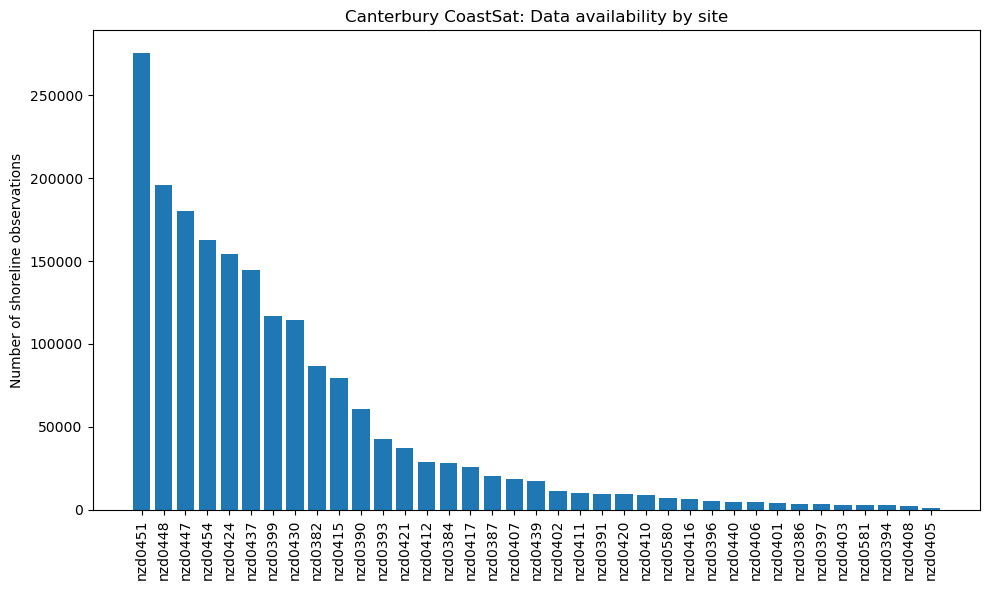

Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\figures\canterbury_coastsat_data_availability_by_site.png


In [7]:
import matplotlib.pyplot as plt

# -----------------------------
# FIGURE: number of shoreline observations per site
# -----------------------------
plt.figure(figsize=(10, 6))
plt.bar(qc_site["site_id"], qc_site["n_obs"])
plt.xticks(rotation=90)
plt.ylabel("Number of shoreline observations")
plt.title("Canterbury CoastSat: Data availability by site")
plt.tight_layout()

outpath = FIG_DIR / "canterbury_coastsat_data_availability_by_site.png"
plt.savefig(outpath, dpi=300)
plt.show()

print("Saved:", outpath)


## Monthly Aggregation of Shoreline Positions

Shoreline observations are irregular in time due to satellite revisit frequency and cloud cover.

To reduce noise and improve comparability:
- Shoreline positions are aggregated to **monthly medians**
- Aggregation is performed separately for each site and transect
- The median is used as a robust statistic that reduces sensitivity to outliers

This step produces a cleaner time series suitable for trend estimation.


In [8]:
# --------------------------------------------
# STEP 1: Monthly aggregation (reduces noise)
# --------------------------------------------
# We compute the median shoreline position per month for each site+transect.
# Median is robust to outliers compared to mean.

shoreline_monthly = (
    shoreline_all
    .dropna(subset=["shoreline_pos"])
    .assign(month=lambda d: d["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["site_id", "transect_id", "month"], as_index=False)
    .agg(
        shoreline_pos=("shoreline_pos", "median"),
        n_in_month=("shoreline_pos", "count")
    )
)

print("Monthly table rows:", len(shoreline_monthly))
display(shoreline_monthly.head())


C:\Users\anura\AppData\Local\Temp\ipykernel_4364\816621501.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda d: d["date"].dt.to_period("M").dt.to_timestamp())


Monthly table rows: 926333


,site_id,transect_id,month,shoreline_pos,n_in_month
0,nzd0382,nzd0382-0000,1999-09-01,329.530,1
1,nzd0382,nzd0382-0000,1999-10-01,340.700,1
2,nzd0382,nzd0382-0000,1999-12-01,336.900,2
3,nzd0382,nzd0382-0000,2000-01-01,335.080,1
4,nzd0382,nzd0382-0000,2000-02-01,335.975,2


In [9]:
shoreline_monthly.to_csv(TAB_DIR / "canterbury_coastsat_monthly_median.csv", index=False)
print("Saved:", TAB_DIR / "canterbury_coastsat_monthly_median.csv")


Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables\canterbury_coastsat_monthly_median.csv


## Estimating Shoreline Change Trends

Linear trends are estimated for each transect to quantify long-term shoreline change.

Method:
- Monthly median shoreline positions are used
- Time is converted to years since the first observation
- A simple linear regression is fitted:
  
  shoreline position = a × time + b

Interpretation:
- Negative slope → shoreline retreat (erosion)
- Positive slope → shoreline advance (accretion)

Trends are reported in **metres per year (m/year)**.


In [10]:
# --------------------------------------------
# STEP 2: Trend per transect (m/year)
# --------------------------------------------
# For each site+transect, fit shoreline_pos ~ time (in years).
# Slope < 0 -> erosion (shoreline retreat), slope > 0 -> accretion (advance)

def fit_trend_m_per_year(df):
    df = df.sort_values("month").dropna(subset=["shoreline_pos"])
    if len(df) < 12:
        # Require at least ~1 year of monthly points (adjust if needed)
        return pd.Series({"slope_m_per_year": np.nan, "n_months": len(df)})

    # Convert time to years since first observation
    t_days = (df["month"] - df["month"].min()).dt.days.values
    t_years = t_days / 365.25
    y = df["shoreline_pos"].values

    # Simple linear fit
    slope, intercept = np.polyfit(t_years, y, 1)

    return pd.Series({"slope_m_per_year": slope, "n_months": len(df)})

transect_trends = (
    shoreline_monthly
    .groupby(["site_id", "transect_id"])
    .apply(fit_trend_m_per_year)
    .reset_index()
)

display(transect_trends.head())
print("Transects with trend:", transect_trends["slope_m_per_year"].notna().sum())


C:\Users\anura\AppData\Local\Temp\ipykernel_4364\2002144735.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fit_trend_m_per_year)


,site_id,transect_id,slope_m_per_year,n_months
0,nzd0382,nzd0382-0000,-0.109740,240.0
1,nzd0382,nzd0382-0001,-0.112943,240.0
2,nzd0382,nzd0382-0002,-0.130573,241.0
3,nzd0382,nzd0382-0003,-0.009876,241.0
4,nzd0382,nzd0382-0004,-0.040325,241.0


Transects with trend: 3589


In [11]:
transect_trends.to_csv(TAB_DIR / "canterbury_transect_trends_m_per_year.csv", index=False)
print("Saved:", TAB_DIR / "canterbury_transect_trends_m_per_year.csv")


Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables\canterbury_transect_trends_m_per_year.csv


## Site-Level Shoreline Change Summary

Transect-level trends are aggregated to the site level to provide a clearer regional picture.

For each site, the following statistics are calculated:
- Number of transects
- Median shoreline trend (m/year)
- Mean shoreline trend
- Interquartile range (25th–75th percentile)
- Minimum and maximum observed trends

These summaries are used to compare erosion and accretion patterns across Canterbury.


In [12]:
# --------------------------------------------
# STEP 3: Site-level summary
# --------------------------------------------
# Summarise distribution of transect trends at each site.

site_trend_summary = (
    transect_trends
    .dropna(subset=["slope_m_per_year"])
    .groupby("site_id", as_index=False)
    .agg(
        n_transects=("transect_id", "nunique"),
        median_trend_m_per_year=("slope_m_per_year", "median"),
        mean_trend_m_per_year=("slope_m_per_year", "mean"),
        p25=("slope_m_per_year", lambda x: np.nanpercentile(x, 25)),
        p75=("slope_m_per_year", lambda x: np.nanpercentile(x, 75)),
        min_trend=("slope_m_per_year", "min"),
        max_trend=("slope_m_per_year", "max"),
    )
    .sort_values("median_trend_m_per_year")
)

display(site_trend_summary.head(10))

site_trend_summary.to_csv(TAB_DIR / "canterbury_site_trend_summary.csv", index=False)
print("Saved:", TAB_DIR / "canterbury_site_trend_summary.csv")


,site_id,n_transects,median_trend_m_per_year,mean_trend_m_per_year,p25,p75,min_trend,max_trend
13,nzd0403,12,-1.324277,-1.175697,-1.504797,-1.147376,-1.892239,0.295277
22,nzd0416,9,-0.682939,-0.684860,-0.801140,-0.568401,-0.869928,-0.504186
26,nzd0424,231,-0.517805,-0.355322,-0.892520,-0.042498,-2.152437,4.996274
0,nzd0382,218,-0.446514,-0.522231,-0.917946,-0.113108,-1.633572,1.243013
21,nzd0415,112,-0.411736,-0.499612,-1.047835,-0.056245,-1.815513,0.495854
15,nzd0406,11,-0.393722,-0.369306,-0.484579,-0.262081,-0.499132,-0.205399
36,nzd0581,5,-0.358863,-0.227404,-0.479197,-0.351268,-0.480400,0.532710
16,nzd0407,45,-0.327439,-0.246890,-0.415571,-0.053211,-0.625865,0.227076
17,nzd0408,5,-0.257915,-0.200517,-0.310820,-0.101675,-0.316924,-0.015249
32,nzd0448,282,-0.242185,-0.209182,-0.524137,-0.016281,-1.569989,1.572218


Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables\canterbury_site_trend_summary.csv


## Visualisation of Shoreline Change Patterns

Two main visualisations are produced:

1. **Histogram of transect trends**
   - Shows the overall distribution of erosion and accretion rates
   - Highlights whether erosion or accretion dominates regionally

2. **Boxplots by site**
   - Compare shoreline change distributions across sites
   - Show variability between transects within each site
   - Zero line indicates no net shoreline change

All figures are exported to the `results/figures` folder for use in reports and presentations.


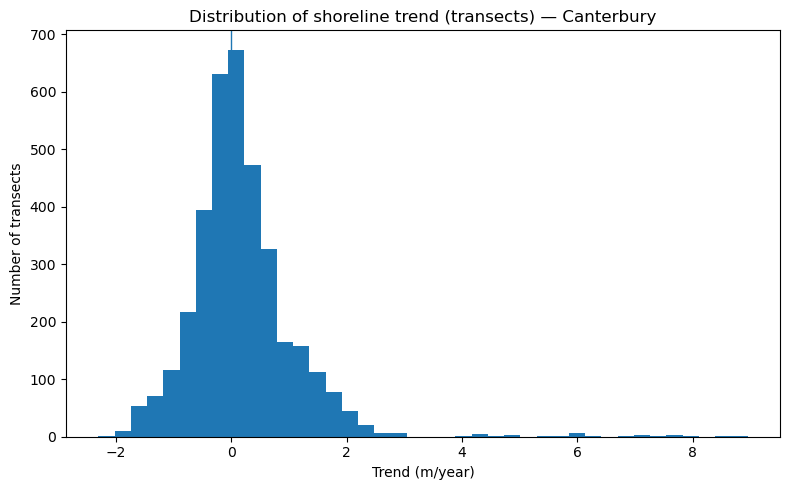

Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\figures\canterbury_transect_trend_histogram.png


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
vals = transect_trends["slope_m_per_year"].dropna()
plt.hist(vals, bins=40)
plt.axvline(0, linewidth=1)
plt.title("Distribution of shoreline trend (transects) — Canterbury")
plt.xlabel("Trend (m/year)")
plt.ylabel("Number of transects")
plt.tight_layout()

outpath = FIG_DIR / "canterbury_transect_trend_histogram.png"
plt.savefig(outpath, dpi=300)
plt.show()
print("Saved:", outpath)


C:\Users\anura\AppData\Local\Temp\ipykernel_4364\1833215681.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=list(top_sites), showfliers=False)


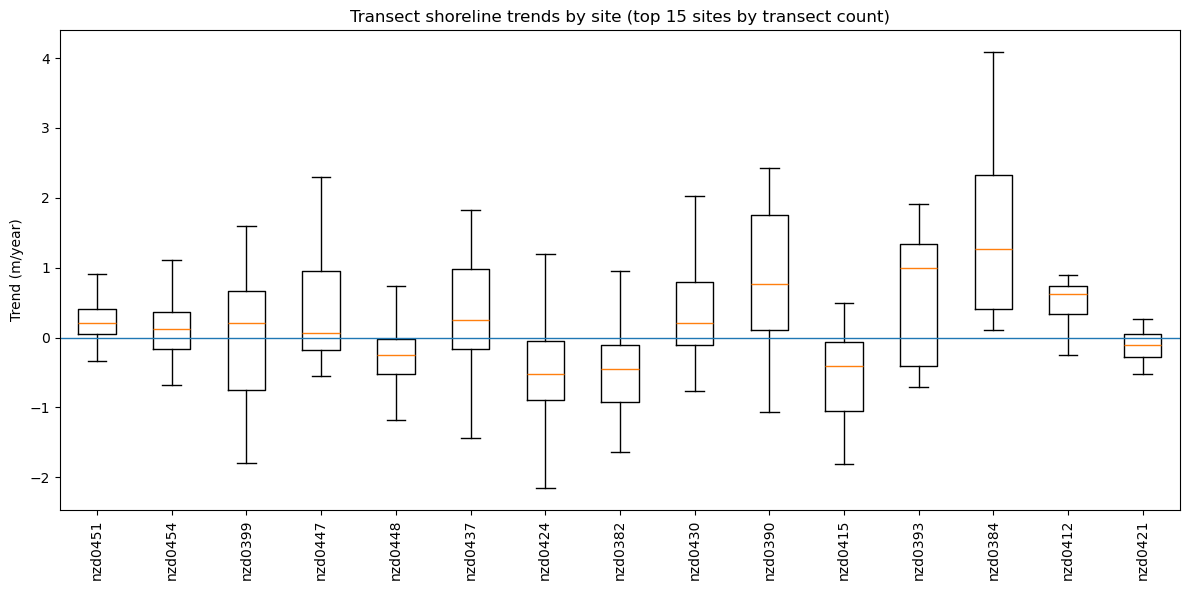

Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\figures\canterbury_trends_boxplot_top15_sites.png


In [14]:
# Select top 15 sites with most transects (keeps figure readable)
top_sites = (
    transect_trends.dropna(subset=["slope_m_per_year"])
    .groupby("site_id")["transect_id"].nunique()
    .sort_values(ascending=False)
    .head(15)
    .index
)

df_plot = transect_trends[
    transect_trends["site_id"].isin(top_sites)
].dropna(subset=["slope_m_per_year"])

# Build list of arrays for boxplot
data = [df_plot[df_plot["site_id"] == s]["slope_m_per_year"].values for s in top_sites]

plt.figure(figsize=(12,6))
plt.boxplot(data, labels=list(top_sites), showfliers=False)
plt.axhline(0, linewidth=1)
plt.xticks(rotation=90)
plt.ylabel("Trend (m/year)")
plt.title("Transect shoreline trends by site (top 15 sites by transect count)")
plt.tight_layout()

outpath = FIG_DIR / "canterbury_trends_boxplot_top15_sites.png"
plt.savefig(outpath, dpi=300)
plt.show()
print("Saved:", outpath)


## Time series of shoreline position (CoastSat)

To visualise temporal shoreline variability, we plot shoreline position through time.  
We show:

1. **One site example** (median across transects per date)  
2. **Top sites** (small multiples)  
3. **Regional signal** (median across sites through time)

These plots complement the spatial trend map by showing *how* shoreline position evolves over time.


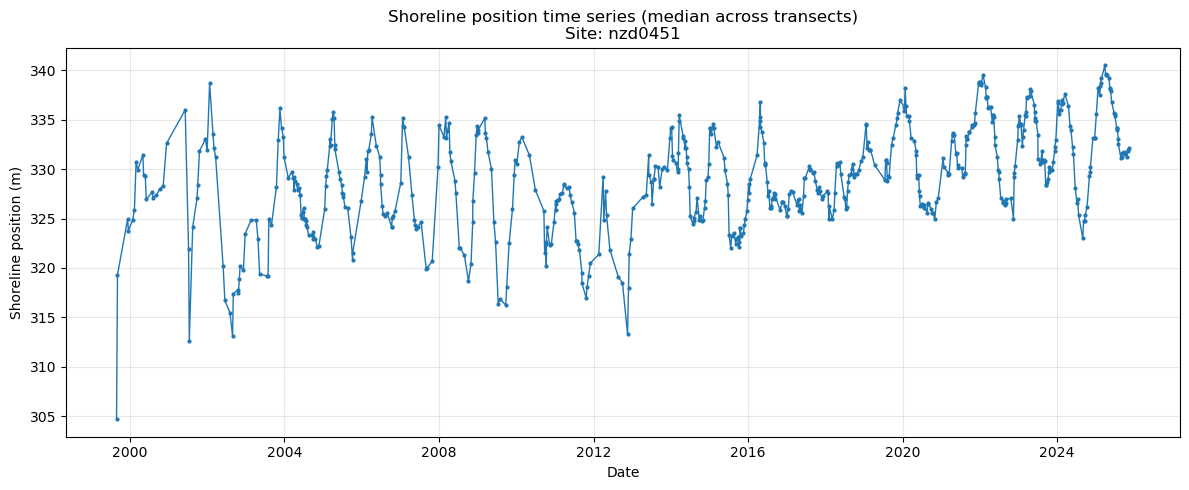

Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\figures\canterbury_timeseries_site_nzd0451.png


In [16]:
# ---------------------------------------------------
# Time series (single site): median shoreline position across transects per date
# ---------------------------------------------------

# Choose a site automatically: most observations (robust, clean plot)
site_best = (
    shoreline_all.dropna(subset=["shoreline_pos"])
    .groupby("site_id")["shoreline_pos"].count()
    .sort_values(ascending=False)
    .index[0]
)

df_site = shoreline_all[
    (shoreline_all["site_id"] == site_best) &
    (shoreline_all["shoreline_pos"].notna())
].copy()

# Ensure datetime
df_site["date"] = pd.to_datetime(df_site["date"], utc=True, errors="coerce")

# Collapse transects -> one value per date
ts_site = (
    df_site.groupby("date")["shoreline_pos"]
    .median()
    .reset_index()
    .sort_values("date")
)

plt.figure(figsize=(12,5))
plt.plot(ts_site["date"], ts_site["shoreline_pos"], marker="o", markersize=2, linewidth=1)
plt.title(f"Shoreline position time series (median across transects)\nSite: {site_best}")
plt.xlabel("Date")
plt.ylabel("Shoreline position (m)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

outpath = FIG_DIR / f"canterbury_timeseries_site_{site_best}.png"
plt.savefig(outpath, dpi=300)
plt.show()
print("Saved:", outpath)


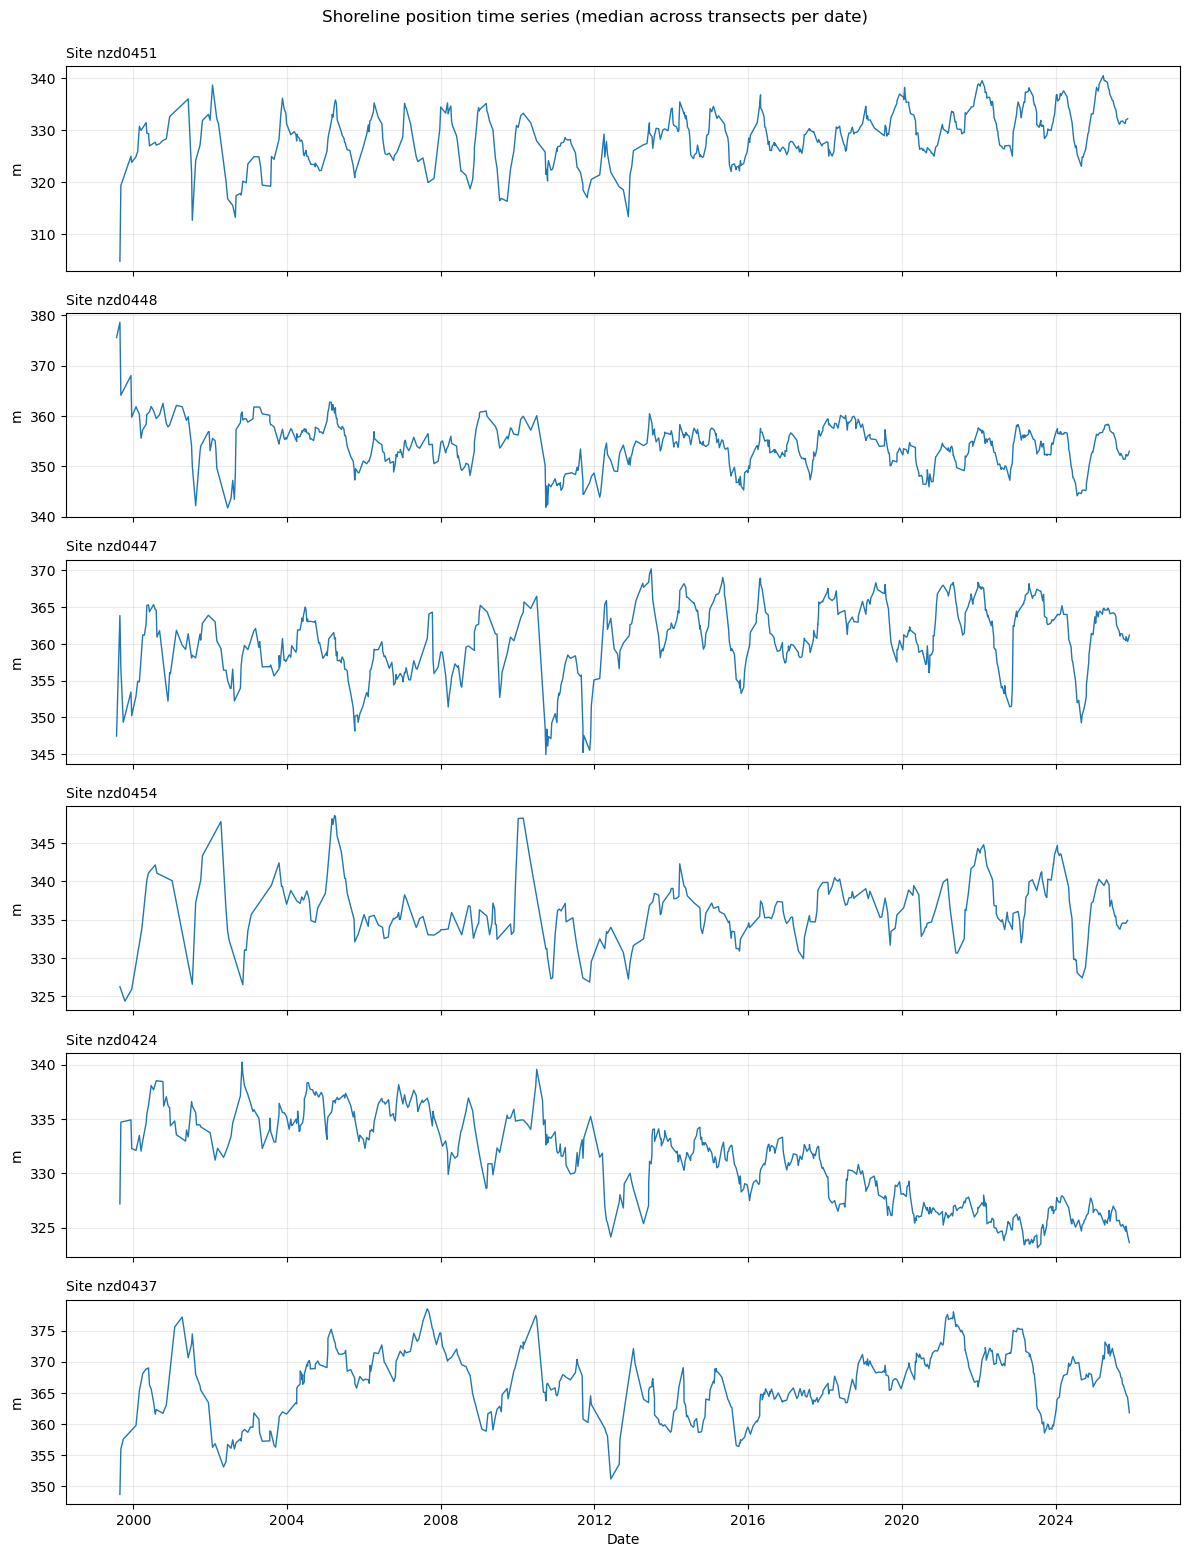

Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\figures\canterbury_timeseries_top6_sites.png


In [17]:
# ---------------------------------------------------
# Time series (small multiples): top N sites by data availability
# ---------------------------------------------------

topN = 6
top_sites_ts = (
    shoreline_all.dropna(subset=["shoreline_pos"])
    .groupby("site_id")["shoreline_pos"].count()
    .sort_values(ascending=False)
    .head(topN)
    .index
)

fig, axes = plt.subplots(topN, 1, figsize=(12, 2.6*topN), sharex=True)

for ax, s in zip(axes, top_sites_ts):
    df_s = shoreline_all[(shoreline_all["site_id"] == s) & shoreline_all["shoreline_pos"].notna()].copy()
    df_s["date"] = pd.to_datetime(df_s["date"], utc=True, errors="coerce")

    ts_s = (
        df_s.groupby("date")["shoreline_pos"]
        .median()
        .reset_index()
        .sort_values("date")
    )

    ax.plot(ts_s["date"], ts_s["shoreline_pos"], linewidth=1)
    ax.set_title(f"Site {s}", loc="left", fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.set_ylabel("m")

axes[-1].set_xlabel("Date")
plt.suptitle("Shoreline position time series (median across transects per date)", y=0.995)
plt.tight_layout()

outpath = FIG_DIR / f"canterbury_timeseries_top{topN}_sites.png"
plt.savefig(outpath, dpi=300)
plt.show()
print("Saved:", outpath)


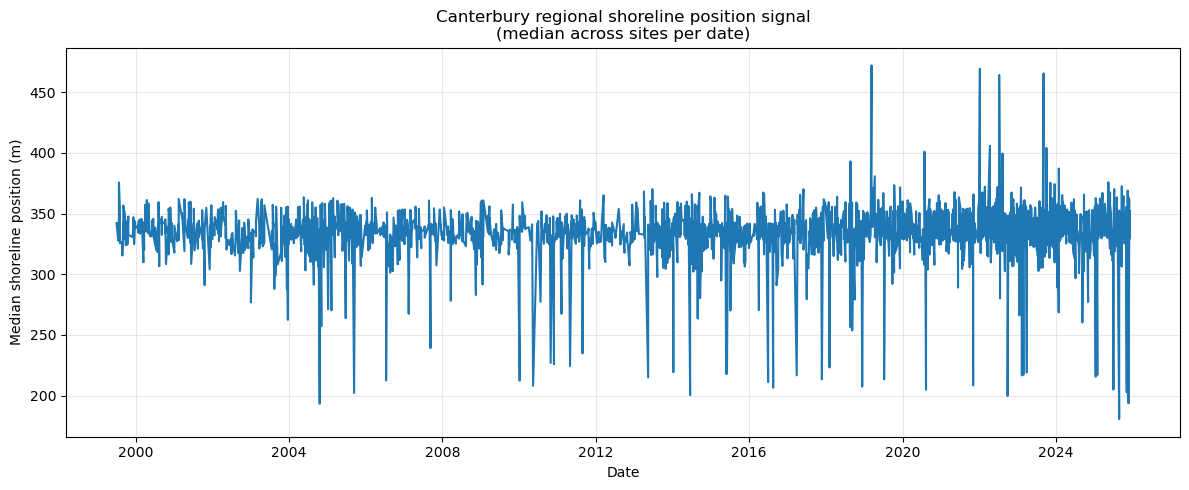

Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\figures\canterbury_timeseries_regional_median.png


In [18]:
# ---------------------------------------------------
# Regional signal: for each site get median per date, then take median across sites
# ---------------------------------------------------

df_all = shoreline_all.dropna(subset=["shoreline_pos"]).copy()
df_all["date"] = pd.to_datetime(df_all["date"], utc=True, errors="coerce")

# Step 1: per site per date
site_date = (
    df_all.groupby(["site_id", "date"])["shoreline_pos"]
    .median()
    .reset_index()
)

# Step 2: across sites per date
region_ts = (
    site_date.groupby("date")["shoreline_pos"]
    .median()
    .reset_index()
    .sort_values("date")
)

plt.figure(figsize=(12,5))
plt.plot(region_ts["date"], region_ts["shoreline_pos"], linewidth=1.5)
plt.title("Canterbury regional shoreline position signal\n(median across sites per date)")
plt.xlabel("Date")
plt.ylabel("Median shoreline position (m)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

outpath = FIG_DIR / "canterbury_timeseries_regional_median.png"
plt.savefig(outpath, dpi=300)
plt.show()
print("Saved:", outpath)


In [21]:
# ---------------------------------------------------------
# STEP 1: Create site-level trend metric from transect trends
# ---------------------------------------------------------
# We use the MEDIAN slope across transects as a robust site-level indicator.

site_trend = (
    transect_trends
    .dropna(subset=["slope_m_per_year"])
    .groupby("site_id", as_index=False)
    .agg(
        n_transects=("transect_id", "nunique"),
        median_slope_m_per_year=("slope_m_per_year", "median"),
        mean_slope_m_per_year=("slope_m_per_year", "mean")
    )
)

display(site_trend.sort_values("median_slope_m_per_year").head(10))




,site_id,n_transects,median_slope_m_per_year,mean_slope_m_per_year
13,nzd0403,12,-1.324277,-1.175697
22,nzd0416,9,-0.682939,-0.684860
26,nzd0424,231,-0.517805,-0.355322
0,nzd0382,218,-0.446514,-0.522231
21,nzd0415,112,-0.411736,-0.499612
15,nzd0406,11,-0.393722,-0.369306
36,nzd0581,5,-0.358863,-0.227404
16,nzd0407,45,-0.327439,-0.246890
17,nzd0408,5,-0.257915,-0.200517
32,nzd0448,282,-0.242185,-0.209182


Coordinates found from tides.csv: 0 / 37
Missing coords (first 10): ['nzd0382', 'nzd0384', 'nzd0386', 'nzd0387', 'nzd0390', 'nzd0391', 'nzd0393', 'nzd0394', 'nzd0396', 'nzd0397']
Added fallback polygon centroids: 37
Sites with coordinates: 37 / 37


C:\Users\anura\AppData\Local\Temp\ipykernel_4364\1794660488.py:99: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poly["centroid"] = poly.geometry.centroid


,site_id,lon,lat,median_slope_m_per_year,n_transects
0,nzd0382,173.942723,-42.104383,-0.446514,218
1,nzd0384,173.899896,-42.187876,1.271717,74
2,nzd0386,173.860631,-42.218067,5.969033,9
3,nzd0387,173.757707,-42.291167,1.274360,50
4,nzd0390,173.703400,-42.361789,0.764873,143
5,nzd0391,173.689175,-42.410742,0.505278,22
6,nzd0393,173.631709,-42.421307,0.992254,103
7,nzd0394,173.530143,-42.478968,1.271349,7
8,nzd0396,173.508406,-42.509164,0.588927,12
9,nzd0397,173.502512,-42.528327,-0.159330,8


Colour scale set to symmetric range: [-3.04, +3.04] m/yr


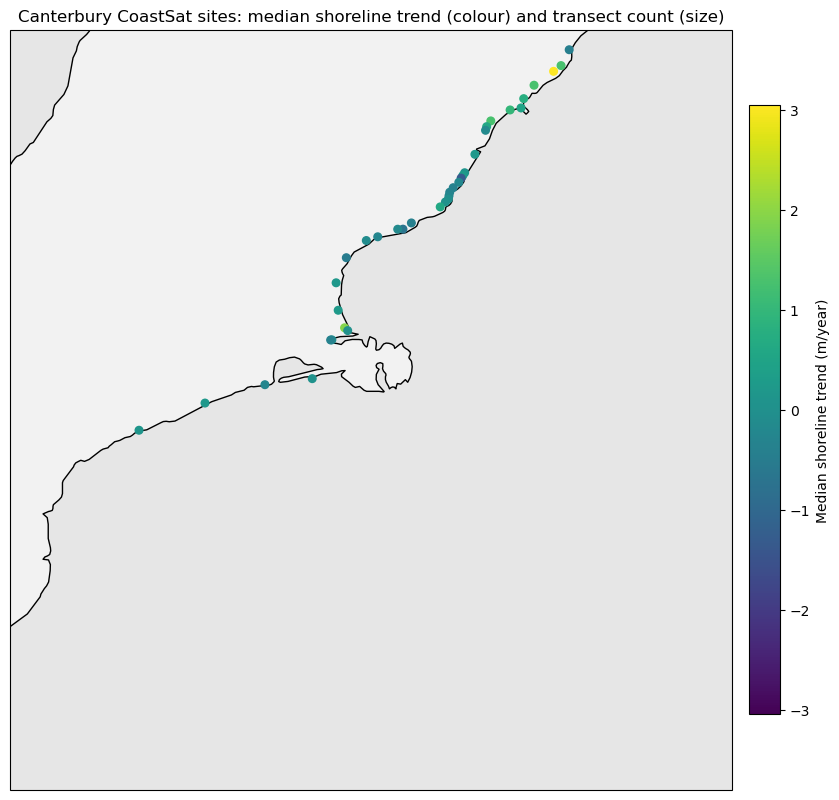

Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\figures\canterbury_summary_map_site_median_trend.png


In [31]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pathlib import Path

# ---------------------------------------------------------
# 1) Build a site -> (lon, lat) table from the site folders
# ---------------------------------------------------------
# Assumes you already have:
# - DATA_DIR = Path(.../CoastSat/data)
# - canterbury_sites = list of "nzd0xxx" strings
# - site_trend dataframe with columns: site_id, n_transects, median_slope_m_per_year (and/or mean_*)
# If any names differ, adjust below.

def _extract_lon_lat_from_tides_csv(tides_path: Path):
    """
    Try to extract lon/lat from tides.csv.
    CoastSat exports sometimes store lon/lat in:
      - comment/header lines (e.g., '# lat: ...', '# lon: ...')
      - columns (e.g., 'lat', 'lon')
    This function tries both approaches.
    Returns (lon, lat) or (None, None).
    """
    if not tides_path.exists():
        return None, None

    # Try header parsing first (fast, avoids loading full file)
    try:
        with open(tides_path, "r", encoding="utf-8", errors="ignore") as f:
            head = "".join([next(f) for _ in range(50)])  # read first 50 lines max
        # Look for patterns like lat = -43.5, lon = 172.7 etc.
        lat_match = re.search(r"lat[^0-9\-]*(-?\d+\.\d+)", head, flags=re.IGNORECASE)
        lon_match = re.search(r"lon[^0-9\-]*(-?\d+\.\d+)", head, flags=re.IGNORECASE)
        if lat_match and lon_match:
            return float(lon_match.group(1)), float(lat_match.group(1))
    except StopIteration:
        pass
    except Exception:
        pass

    # Try reading as a dataframe and looking for columns
    try:
        df = pd.read_csv(tides_path)
        cols = [c.lower() for c in df.columns]
        if ("lon" in cols) and ("lat" in cols):
            lon_col = df.columns[cols.index("lon")]
            lat_col = df.columns[cols.index("lat")]
            lon = pd.to_numeric(df[lon_col], errors="coerce").dropna()
            lat = pd.to_numeric(df[lat_col], errors="coerce").dropna()
            if len(lon) and len(lat):
                return float(lon.iloc[0]), float(lat.iloc[0])
    except Exception:
        pass

    return None, None


coords = []
missing = []

for sid in canterbury_sites:
    site_folder = DATA_DIR / sid
    tides_path = site_folder / "tides.csv"

    lon, lat = _extract_lon_lat_from_tides_csv(tides_path)

    if (lon is None) or (lat is None) or (np.isnan(lon)) or (np.isnan(lat)):
        missing.append(sid)
    else:
        coords.append({"site_id": sid, "lon": lon, "lat": lat})

coords_df = pd.DataFrame(coords)
print(f"Coordinates found from tides.csv: {len(coords_df)} / {len(canterbury_sites)}")
if len(missing):
    print("Missing coords (first 10):", missing[:10])

# ---------------------------------------------------------
# 2) Fallback: try polygons.geojson centroid for missing sites
# ---------------------------------------------------------
# NOTE: polygons.geojson in your repo might contain IDs that don't match nzd****,
# but we try anyway in case there is a match in your local clone.
try:
    polygons_path = REPO / "polygons.geojson"
    if polygons_path.exists() and len(missing) > 0:
        poly = gpd.read_file(polygons_path)
        # Ensure CRS set if missing
        if poly.crs is None:
            poly = poly.set_crs(4326, allow_override=True)

        # If geometry is already lon/lat degrees, centroid is okay for approximate site location
        poly["centroid"] = poly.geometry.centroid
        poly["lon_poly"] = poly["centroid"].x
        poly["lat_poly"] = poly["centroid"].y

        poly["id"] = poly["id"].astype(str)
        poly_nz = poly[poly["id"].str.startswith("nzd")].copy()

        if len(poly_nz):
            fallback = poly_nz[poly_nz["id"].isin(missing)][["id", "lon_poly", "lat_poly"]].rename(
                columns={"id": "site_id", "lon_poly": "lon", "lat_poly": "lat"}
            )
            if len(fallback):
                coords_df = pd.concat([coords_df, fallback], ignore_index=True)
                print(f"Added fallback polygon centroids: {len(fallback)}")
except Exception as e:
    print("Polygon centroid fallback skipped due to error:", e)

# ---------------------------------------------------------
# 3) Merge coords + trends into one mapping dataframe
# ---------------------------------------------------------
# site_trend from your previous cell
map_df = site_trend.merge(coords_df, on="site_id", how="left")

print("Sites with coordinates:", map_df["lon"].notna().sum(), "/", len(map_df))
display(map_df[["site_id", "lon", "lat", "median_slope_m_per_year", "n_transects"]].head(10))

# Drop sites still missing coords
map_df = map_df.dropna(subset=["lon", "lat"]).copy()

# ---------------------------------------------------------
# 4) Plot map using Cartopy (explicit colour scaling)
# ---------------------------------------------------------
# Robust colour limits so points are not all white.
# We clip to 2nd–98th percentile to avoid 1 outlier dominating the colourbar.
vals = map_df["median_slope_m_per_year"].astype(float)
vmin = np.nanpercentile(vals, 2)
vmax = np.nanpercentile(vals, 98)

# If vmin/vmax collapse (rare), force a symmetric range around 0
if not np.isfinite(vmin) or not np.isfinite(vmax) or (abs(vmax - vmin) < 1e-9):
    m = np.nanmax(np.abs(vals))
    vmin, vmax = -m, m

# Map extent (Canterbury coast-ish); tweak if you want tighter/looser framing
extent = [171.0, 174.8, -46.0, -42.0]  # [lon_min, lon_max, lat_min, lat_max]

# Point size scale based on transect count
# (keeps sizes sane across sites)
size = map_df["n_transects"].clip(lower=1)
sizes = 20 + 4 * np.sqrt(size)  # simple readable scaling

fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Basemap
ax.add_feature(cfeature.LAND, facecolor="0.95", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="0.90", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=1)

vals = map_df["median_slope_m_per_year"].dropna().values

# Robust range: use 2nd–98th percentiles to avoid 1-2 extreme sites dominating the colourbar
lo, hi = np.percentile(vals, [2, 98])
vmax = max(abs(lo), abs(hi))

# Force symmetric around 0
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

print(f"Colour scale set to symmetric range: [-{vmax:.2f}, +{vmax:.2f}] m/yr")

# Scatter points
sc = ax.scatter(
    map_df["lon"], map_df["lat"],
    c=map_df["median_slope_m_per_year"],
    norm=norm,
    s=30,
    transform=ccrs.PlateCarree()
)

cb = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cb.set_label("Median shoreline trend (m/year)")

plt.title("Canterbury CoastSat sites: median shoreline trend (colour) and transect count (size)")
plt.tight_layout()

outpath = FIG_DIR / "canterbury_summary_map_site_median_trend.png"
plt.savefig(outpath, dpi=300)
plt.show()
print("Saved:", outpath)
